In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from keras import regularizers
from keras import initializers

# =========================
# CONFIG
# =========================
TS = 0.07
TIME_STEPS = 15
BATCH_SIZE = 32
EPOCHS = 100

DATA_PATH = "./Data/Datasets.xlsx"

TARGET_NAME = "Theta"
PREDICTORS = ["PwmD", "PwmE", "sPwm", "dPwm"]

TITLES = ["Train_1", "Train_2", "Val_1", "Val_2", "Test_1", "Test_2", "LSG_1", "LSG_2"]


In [43]:
# =========================
# SLIDING WINDOW
# =========================
def create_sequences(pred, target, time_steps):
    Xs, ys = [], []
    for i in range(len(pred) - time_steps):
        Xs.append(pred[i:i+time_steps])
        ys.append(target[i+time_steps])
    return np.array(Xs), np.array(ys)

# =========================
# LOAD TREINO
# =========================
df_train = pd.concat([
    pd.read_excel(DATA_PATH, sheet_name="Train_1"),
    pd.read_excel(DATA_PATH, sheet_name="Train_2")
])

Out_train = df_train[TARGET_NAME].values
dOut_train = df_train[f"d{TARGET_NAME}"].values

Inp_train = df_train[PREDICTORS].values

# =========================
# LOAD VAL
# =========================
df_val = pd.concat([
    pd.read_excel(DATA_PATH, sheet_name="Val_1"),
    pd.read_excel(DATA_PATH, sheet_name="Val_2")
])

dOut_val = df_val[f"d{TARGET_NAME}"].values
Inp_Val = df_val[PREDICTORS].values


# =========================
# LOAD Physics
# =========================
Theta_p = df_train["Theta"].values
Wd_p = df_train["Wd"].values
We_p = df_train["We"].values

# =========================
# NORMALIZAÇÃO 
# =========================
InpScaler = StandardScaler()
OutScaler = StandardScaler()

Inp_train = InpScaler.fit_transform(Inp_train)
dOut_train = OutScaler.fit_transform(dOut_train.reshape(-1, 1)).flatten()

Inp_val = InpScaler.transform(Inp_Val)
dOut_val  = OutScaler.transform(dOut_val.reshape(-1, 1)).flatten()

# =========================
# Sequencias 
# =========================
_, Wd_p = create_sequences(Inp_train, Wd_p, TIME_STEPS)
_, We_p = create_sequences(Inp_train, We_p, TIME_STEPS)
_, Theta_p = create_sequences(Inp_train, Theta_p, TIME_STEPS)

Inp_train, dOut_train = create_sequences(Inp_train, dOut_train, TIME_STEPS)
Inp_val, dOut_val = create_sequences(Inp_val, dOut_val, TIME_STEPS)


In [44]:
mean_tf = tf.constant(OutScaler.mean_[0], dtype=tf.float32)
std_tf  = tf.constant(OutScaler.scale_[0], dtype=tf.float32)  

In [45]:
# =========================
# MODELO 
# =========================
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

initializer = tf.keras.initializers.GlorotUniform(seed=SEED)
recurrent_initializer = tf.keras.initializers.Orthogonal(seed=SEED)

l2_reg = tf.keras.regularizers.l2(1e-4)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(TIME_STEPS, len(PREDICTORS))),
    
    tf.keras.layers.SimpleRNN(
        32,
        activation='tanh',
        kernel_initializer=initializer,
        recurrent_initializer=recurrent_initializer,
        bias_initializer='zeros',
        kernel_regularizer=l2_reg,
        recurrent_regularizer=l2_reg
    ),
    
    tf.keras.layers.Dense(
        1,
        activation='linear',
        kernel_initializer=initializer,
        bias_initializer='zeros',
        kernel_regularizer=l2_reg
    )
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='mse'
)

In [ ]:
# =========================
# HIPERPARÂMETROS PIRNN
# =========================
Ld = 1.0
Lp = 0.1  

optimizer = tf.keras.optimizers.Adam(1e-3)

# =========================
# TRAIN STEP
# =========================
R = tf.constant(0.0328, dtype=tf.float32)
L = tf.constant(0.0615, dtype=tf.float32)
dt = tf.constant(TS, dtype=tf.float32)

def CinematicModel(Wd, We, theta):
    if TARGET_NAME == "Theta": 
        return (R / (2 * L)) * (Wd - We)
    if TARGET_NAME == "X": 
        return (R / 2) * tf.cos(theta) * (Wd + We)
    if TARGET_NAME == "Y": 
        return (R / 2) * tf.sin(theta) * (Wd + We)

@tf.function
def train_step(model, optimizer, Inp, dOut, Wd, We, theta):
    alpha = 2.0
    # weights = 1 + alpha * tf.abs(dOut)
    weights = 1

    with tf.GradientTape() as tape:
        # FeedForward
        dOut_pred = model(Inp, training=True)

        # Data Loss
        data_loss = tf.reduce_mean(weights * tf.square(dOut_pred - dOut))

        # Physics
        dOutCin = CinematicModel(Wd, We, theta)
        dOutCin = (dOutCin - mean_tf) / std_tf

        #  Physics Loss
        physics_loss = tf.reduce_mean(tf.square(dOut_pred - dOutCin))

        loss = Ld * data_loss + Lp * physics_loss

    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    return data_loss, physics_loss

In [47]:
for epoch in range(EPOCHS):

    loss_d_epoch = []
    loss_f_epoch = []

    for i in range(0, len(Inp_train), BATCH_SIZE):

        Inp_b = Inp_train[i:i+BATCH_SIZE]
        dOut_b = dOut_train[i:i+BATCH_SIZE]
        Theta_b = Theta_p[i:i+BATCH_SIZE]
        Wd_b = Wd_p[i:i+BATCH_SIZE]
        We_b = We_p[i:i+BATCH_SIZE]
        

        ld, lf = train_step(
            model,
            optimizer,
            tf.convert_to_tensor(Inp_b, tf.float32),
            tf.convert_to_tensor(dOut_b.reshape(-1,1), tf.float32),
            tf.convert_to_tensor(Theta_b, tf.float32),
            tf.convert_to_tensor(Wd_b, tf.float32),
            tf.convert_to_tensor(We_b, tf.float32),
)

        loss_d_epoch.append(ld.numpy())
        loss_f_epoch.append(lf.numpy())

    print(f"Epoch {epoch+1} | Ld={np.mean(loss_d_epoch):.4f} | Lf={np.mean(loss_f_epoch):.4f}")


Epoch 1 | Ld=3.3443 | Lf=19.0903
Epoch 2 | Ld=2.4010 | Lf=17.2597
Epoch 3 | Ld=2.0936 | Lf=17.6370
Epoch 4 | Ld=1.8861 | Lf=17.7348
Epoch 5 | Ld=1.7218 | Lf=17.8485
Epoch 6 | Ld=1.5969 | Lf=17.9328
Epoch 7 | Ld=1.5172 | Lf=17.9331
Epoch 8 | Ld=1.4702 | Lf=17.8832
Epoch 9 | Ld=1.4177 | Lf=17.9131
Epoch 10 | Ld=1.3474 | Lf=17.9982
Epoch 11 | Ld=1.2861 | Lf=18.0006
Epoch 12 | Ld=1.2368 | Lf=17.9889
Epoch 13 | Ld=1.1794 | Lf=17.9904
Epoch 14 | Ld=1.1199 | Lf=17.9387
Epoch 15 | Ld=1.0503 | Lf=17.8524
Epoch 16 | Ld=0.9947 | Lf=17.8474
Epoch 17 | Ld=0.9410 | Lf=17.8581
Epoch 18 | Ld=0.9321 | Lf=17.8686
Epoch 19 | Ld=0.8805 | Lf=17.7926
Epoch 20 | Ld=0.8438 | Lf=17.7784
Epoch 21 | Ld=0.8201 | Lf=17.8596
Epoch 22 | Ld=0.7983 | Lf=17.7702
Epoch 23 | Ld=0.7842 | Lf=17.9090
Epoch 24 | Ld=0.8121 | Lf=17.7120
Epoch 25 | Ld=0.7614 | Lf=17.7992
Epoch 26 | Ld=0.8007 | Lf=17.7433
Epoch 27 | Ld=0.7808 | Lf=17.8309
Epoch 28 | Ld=0.7253 | Lf=17.7571
Epoch 29 | Ld=0.7237 | Lf=17.7417
Epoch 30 | Ld=0.6793 | 

Train_1 | R2 dOut_test: 0.7872 | R2 Theta: -0.1861
Train_2 | R2 dOut_test: 0.8744 | R2 Theta: -5.8291
Val_1 | R2 dOut_test: 0.5116 | R2 Theta: 0.2929
Val_2 | R2 dOut_test: 0.8771 | R2 Theta: -8.1663
Test_1 | R2 dOut_test: 0.1362 | R2 Theta: -0.7426
Test_2 | R2 dOut_test: 0.1286 | R2 Theta: 0.3584
LSG_1 | R2 dOut_test: 0.5380 | R2 Theta: 0.1234
LSG_2 | R2 dOut_test: 0.6997 | R2 Theta: -0.2869


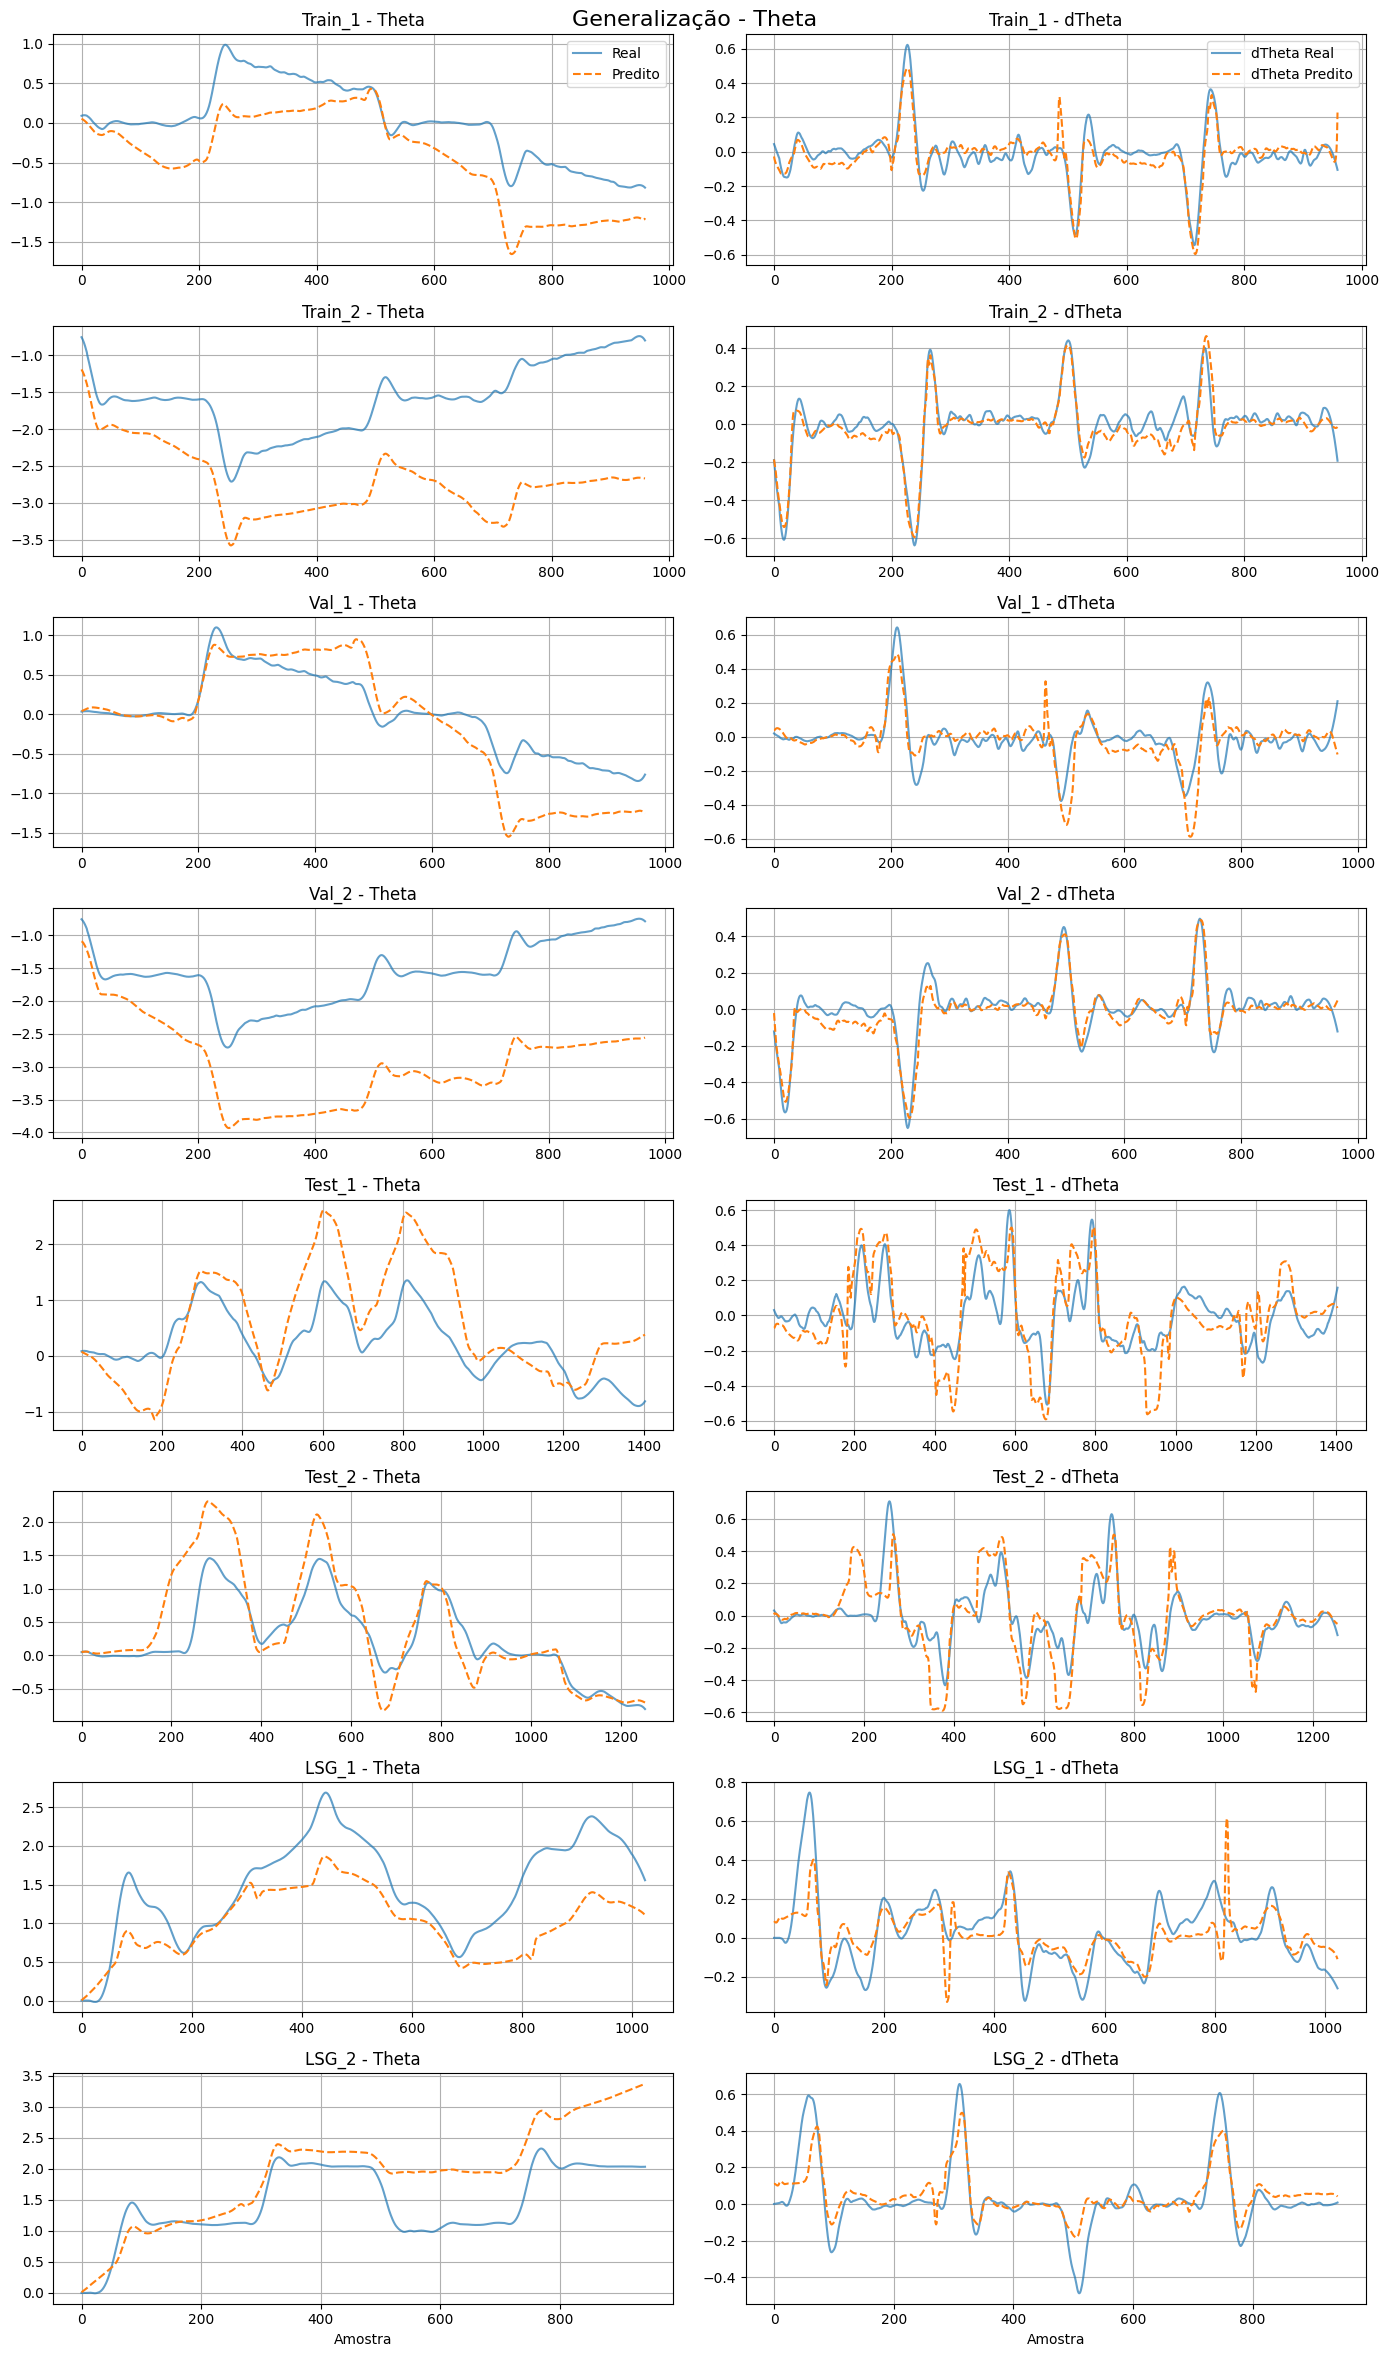

In [48]:
# =========================
# Teste
# =========================
n = len(TITLES)
fig, axs = plt.subplots(n, 2, figsize=(14, 3*n))

for i, title in enumerate(TITLES):

    df_test = pd.read_excel(DATA_PATH, sheet_name=title)

    Out_test_true = df_test[TARGET_NAME].values
    dOut_test_true = df_test[f"d{TARGET_NAME}"].values

    Inp_test = df_test[PREDICTORS].values

    Inp_test_scaled = InpScaler.transform(Inp_test)   
    Inp_test, Out_test_true = create_sequences(Inp_test_scaled, Out_test_true, TIME_STEPS)
    _, dOut_test_true = create_sequences(Inp_test_scaled, dOut_test_true, TIME_STEPS)
    
    # predição normalizada
    dOut_test_pred = model.predict(Inp_test, verbose=0)
    # predição desnormalizada
    dOut_test_pred = OutScaler.inverse_transform(dOut_test_pred)

    # =========================
    # RECONSTRUÇÃO 
    # =========================
    Out_test_true_0 = Out_test_true[TIME_STEPS:][0]
    Out_test_rec = np.zeros_like(Out_test_true.flatten())
    Out_test_pred = Out_test_true_0 + np.cumsum(dOut_test_pred.flatten() * TS)

    # =========================
    # PLOT TARGET
    # =========================
    axs[i, 0].plot(Out_test_true, label="Real", alpha=0.7)
    axs[i, 0].plot(Out_test_pred, label="Predito", linestyle='--')

    axs[i, 0].set_title(f"{title} - {TARGET_NAME}")
    axs[i, 0].grid(True)

    if i == 0:
        axs[i, 0].legend()

    # =========================
    # PLOT DERIVADA
    # =========================
    axs[i, 1].plot(dOut_test_true, label=f"d{TARGET_NAME} Real", alpha=0.7)
    axs[i, 1].plot(dOut_test_pred, label=f"d{TARGET_NAME} Predito", linestyle='--')

    axs[i, 1].set_title(f"{title} - d{TARGET_NAME}")
    axs[i, 1].grid(True)

    if i == 0:
        axs[i, 1].legend()
    r2_dOut_test = r2_score(dOut_test_true.flatten(), dOut_test_pred.flatten())
    r2_Out_test  = r2_score(Out_test_true.flatten(), Out_test_pred.flatten())
    print(f"{title} | R2 dOut_test: {r2_dOut_test:.4f} | R2 Theta: {r2_Out_test:.4f}")

axs[-1, 0].set_xlabel("Amostra")
axs[-1, 1].set_xlabel("Amostra")

plt.suptitle(f"Generalização - {TARGET_NAME}", fontsize=16)
plt.tight_layout()
plt.show()